# 🎓 *Del dato a la decisión: fundamentos de experimentación A/B*


---

🎯 *Objetivos académicos*

* Aplicar los criterios ICE y RICE para evaluar hipótesis y tomar decisiones informadas.
* Comprender los fundamentos de la verificación de hipótesis y su aplicación en negocios.


---


## 📌 *¿Por qué experimentar en negocios?*

En un entorno competitivo, las decisiones deben estar respaldadas por datos. El enfoque *data-driven* permite tomar decisiones informadas en lugar de actuar por intuición. Experimentar permite validar ideas, reducir riesgos y maximizar impacto con evidencia.

**Ejemplos de experimentos en negocios:**
* *Cualitativo*: entrevistas para conocer motivaciones de cancelación de suscripciones.
* *Cuantitativo*: test A/B para evaluar si una nueva oferta mejora la tasa de conversión.
* *Test A/A*: evaluar si la infraestructura de medición es confiable.

> *Una empresa que decide rediseñar su landing page debe medir el impacto del cambio, no solo lanzarlo a ciegas.*

---


### 🧪 *¿Qué hace buena una experimentación cuantitativa?*

Todo parte de una **hipótesis clara, medible y comprobable**. Si una hipótesis es ambigua o demasiado general, los resultados no ofrecerán conclusiones útiles.

**Ejemplo de hipótesis vaga:**
> Cambiar la página principal mejorará la experiencia del usuario.

**Ejemplo de hipótesis clara:**
> Si reducimos el tiempo de carga de la homepage en un 30%, la tasa de conversión aumentará al menos un 5%.

🔑 Criterios para una buena hipótesis:
* Clara y específica
* Medible con una métrica relevante
* Falsable
* Basada en observaciones o datos previos

---

<center>
  <img src="https://www.explainxkcd.com/wiki/images/1/1b/hypothesis_generation.png" alt="Espacios de trabajo en Git" style="max-width:100%; height:auto;"  width="60%">
</center>


### 💡 Analiza las siguientes hipótesis 

1. **"Cambiar el color del botón principal aumentará las ventas."**

2. **"Si reducimos el tiempo de carga de la página de inicio en un 30%, la tasa de conversión aumentará al menos un 5%."**

3. **"Mejorar la experiencia del usuario hará que más personas recomienden el sitio."**


👉 Analiza cada una y responde:  
- ¿Cuál es una buena hipótesis?  
- ¿Cuáles no lo son y por qué?



### 📊 *¿Cómo decidir qué hipótesis probar?*

---

En la práctica, suele haber muchas ideas o hipótesis posibles para experimentar, pero los recursos (tiempo, dinero, usuarios) son limitados. Por eso, es fundamental priorizar de forma objetiva cuáles hipótesis tienen mayor potencial de impacto y probabilidad de éxito. Para esto, existen frameworks como **ICE** y **RICE**, que ayudan a comparar y ordenar hipótesis de manera estructurada.

📋 *Framework ICE*

Evalúa cada hipótesis según tres criterios: **Impacto** (Impact), **Confianza** (Confidence) y **Esfuerzo** (Effort). La puntuación se calcula así:

$$
ICE = \frac{\text{Impacto} \times \text{Confianza}}{\text{Esfuerzo}}
$$

📋 *Framework RICE*

Agrega un cuarto criterio: **Alcance** (Reach), es decir, cuántos usuarios se verán afectados por el cambio. La fórmula es:

$$
RICE = \frac{\text{Alcance} \times \text{Impacto} \times \text{Confianza}}{\text{Esfuerzo}}
$$

Estos frameworks permiten priorizar de forma transparente y alineada con los objetivos


In [16]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from itertools import combinations


In [17]:
sns.set(style="whitegrid", palette="pastel")


In [18]:
hipotesis = pd.DataFrame({
    'idea': ['Agregar CTA', 'Reducir pasos de compra', 'Cambiar color del botón'],
    'reach': [8, 6, 9],
    'impact': [7, 9, 4],
    'confidence': [8, 6, 5],
    'effort': [3, 7, 2]
})



In [19]:
hipotesis

,idea,reach,impact,confidence,effort
0,Agregar CTA,8,7,8,3
1,Reducir pasos de compra,6,9,6,7
2,Cambiar color del botón,9,4,5,2


In [20]:
hipotesis['ICE'] = (hipotesis['impact'] * hipotesis['confidence']) / hipotesis['effort']
hipotesis['RICE'] = (hipotesis['reach'] * hipotesis['impact'] * hipotesis['confidence']) / hipotesis['effort']

hipotesis.round().sort_values(by='RICE', ascending=False)

,idea,reach,impact,confidence,effort,ICE,RICE
0,Agregar CTA,8,7,8,3,19.0,149.0
2,Cambiar color del botón,9,4,5,2,10.0,90.0
1,Reducir pasos de compra,6,9,6,7,8.0,46.0


---

## 🔬 *Pruebas A/B: Diseño de un buen test*

---

Una prueba A/B compara dos versiones de algo para identificar cuál tiene mejor rendimiento en una métrica clave.

### Prueba para medias

Una tienda en línea lanzó una nueva versión del checkout (grupo B) que incluye recomendaciones y resumen de costos más claro. El equipo de producto quiere saber si esta versión incrementa el *ticket promedio por sesión* frente a la versión actual (grupo A). Para ello, se ejecuta un A/B test con usuarios asignados aleatoriamente a cada grupo.

**🧪Objetivo del experimento:**  
Evaluar si la nueva versión (grupo B) aumenta el *ticket promedio por sesión* respecto a la versión actual (grupo A).

**Métrica principal (continua):**  
*Ticket promedio por sesión* en USD (promedio del gasto por usuario/sesión).

**Hipótesis estadísticas (para medias):**  
- **H₀ (hipótesis nula):** No hay diferencia en el ticket promedio entre A y B: $\,\mu_A = \mu_B\,$.  
- **H₁ (hipótesis alternativa, direccional):** El ticket promedio del grupo B es mayor que el de A: $\,\mu_B > \mu_A\,$.


**Diseño experimental:**  
* **Tipo de experimento:** Prueba A/B clásica (2 grupos independientes)  
* **Asignación:** Aleatoria (simulada con distribución normal)  
* **Nivel de significancia ($\alpha$):** 0.05  


In [29]:
ab_test_checkout_purchase=pd.read_csv("https://raw.githubusercontent.com/zyntonyson/bootcamp_ds_da/refs/heads/main/datasets/s_10_a_b_mean_test.csv")

In [30]:
ab_test_checkout_purchase.head()

,group,amount,ts_visit,uuid_user
0,B,1751.22,2025-08-05 08:49:47,b04965e6-a9bb-591f-8f8a-1adcb2c8dc39
1,B,1767.45,2025-04-25 17:11:13,4b166dbe-d99d-5091-abdd-95b83330ed3a
2,B,1803.20,2025-08-05 15:38:12,98123fde-012f-5ff3-8b50-881449dac91a
3,B,1792.09,2025-05-06 19:00:28,6ed955c6-506a-5343-9be4-2c0afae02eef
4,B,1799.58,2025-05-16 17:19:39,c8691da2-158a-5ed6-8537-0e6f140801f2


In [32]:
(ab_test_checkout_purchase
    .groupby('group',as_index=False)
    .agg(
        n_clients =('uuid_user','nunique'),
        avg_ticket = ('amount','mean')
    )
    .round()
 )

,group,n_clients,avg_ticket
0,A,417,1598.0
1,B,379,1800.0



### Prueba para proporciones

<Axes: xlabel='group', ylabel='amount'>

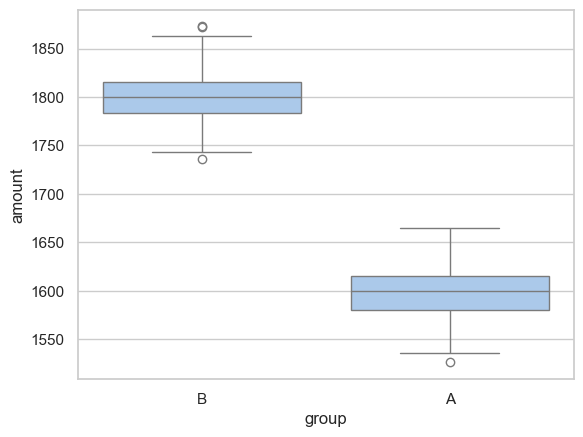

In [33]:
sns.boxplot(data=ab_test_checkout_purchase,x='group',y='amount')

In [40]:
treatment =ab_test_checkout_purchase.query("group =='B'")['amount'].to_list()
control =ab_test_checkout_purchase.query("group =='A'")['amount'].to_list()
alpha = 0.05

In [39]:
stat,p_value = ttest_ind(treatment,control,alternative='greater')

print(f"Tenemos un {p_value=:.3f} entonces con {alpha=} ")
if p_value > alpha:
    print(f"No hay evidencia de que las tasas de conversión sean diferentes")
else:
    print(f"Hay evidencia de que las tasas de conversión sean diferentes")
    

Tenemos un p_value=0.000 entonces con alpha=0.05 
Hay evidencia de que las tasas de conversión sean diferentes



**🧪Objetivo del experimento:**  
Evaluar si una nueva versión de una página web (grupo B) mejora la tasa de conversión respecto a la versión actual (grupo A).

**Métrica principal:**  
*Conversión binaria*, es decir, si un usuario realizó o no una acción objetivo (por ejemplo: compra, registro o clic).

**Hipótesis estadísticas:**

- **H₀ (hipótesis nula):** No hay diferencia en la tasa de conversión entre los grupos A y B ($p_A = p_B$).
- **H₁ (hipótesis alternativa):** La tasa de conversión del grupo B es diferente a la del grupo A ($p_A \ne p_B$).

**Diseño experimental:**

* **Tipo de experimento:** Prueba A/B clásica (2 grupos independientes)
* **Asignación:** Aleatoria (simulada con distribución binomial)
* **Duración:** Equivalente a una muestra de 1000 usuarios por grupo
* **Nivel de significancia ($\alpha$):** 0.05

---

📄 **Diccionario de datos**

| Variable     | Tipo       | Descripción                                              |
|--------------|------------|----------------------------------------------------------|
| grupo        | categórica | Grupo asignado al usuario: 'A' (control) o 'B' (test)    |
| conversion   | binaria    | Resultado: 1 si convirtió, 0 si no convirtió             |




In [21]:
ab_test_landing_page_data=pd.read_csv("https://raw.githubusercontent.com/30lm32/ml-ab-testing/refs/heads/master/ab_data.csv")

In [22]:
treatment = ab_test_landing_page_data.query("group =='treatment'")['converted'].to_list()
control = ab_test_landing_page_data.query("group =='control'")['converted'].to_list()
alpha = 0.05

In [23]:
(
    ab_test_landing_page_data
        .groupby('group',as_index=False)
        .agg(
            rate =('converted','mean')
        )
        .round(3)
)

,group,rate
0,control,0.120
1,treatment,0.119


In [26]:
x_treatment, n_treatment = sum(treatment),len(treatment)
x_control, n_control = sum(control),len(control)

count=[x_treatment,  x_control]
n_obs =[n_treatment,n_control]
count,n_obs

([17514, 17723], [147276, 147202])

In [27]:
stat,p_value = proportions_ztest(count, n_obs, alternative='larger')

print(f"Tenemos un {p_value=:.3f} entonces con {alpha=} ")
if p_value > alpha:
    print(f"No hay evidencia de que las tasas de conversión sean diferentes")
else:
    print(f"Hay evidencia de que las tasas de conversión sean diferentes")

Tenemos un p_value=0.892 entonces con alpha=0.05 
No hay evidencia de que las tasas de conversión sean diferentes


In [28]:
stat,p_value = ttest_ind(treatment,control,alternative='greater')

print(f"Tenemos un {p_value=:.3f} entonces con {alpha=} ")
if p_value > alpha:
    print(f"No hay evidencia de que las tasas de conversión sean diferentes")
else:
    print(f"Hay evidencia de que las tasas de conversión sean diferentes")
    

Tenemos un p_value=0.892 entonces con alpha=0.05 
No hay evidencia de que las tasas de conversión sean diferentes


### ⚠️ *Errores comunes*

Cuando realizamos una prueba estadística, siempre existe la posibilidad de equivocarnos al sacar conclusiones. Estos errores se clasifican en dos tipos:

---

**• Tipo I ($\alpha$): Falso positivo**  
Rechazamos la hipótesis nula ($H_0$) cuando en realidad es cierta.

> Ejemplo: Concluyes que una nueva versión mejora la conversión, pero en realidad no lo hace. Has sido engañado por la variabilidad aleatoria.

**$\alpha$ representa la probabilidad de cometer este error.**  
Por eso normalmente se fija en 0.05 (5%), lo que implica aceptar un 5% de riesgo de falso positivo.

---

**• Tipo II ($\beta$): Falso negativo**  
No rechazamos la hipótesis nula cuando en realidad es falsa.

> Ejemplo: No detectas que la nueva versión mejora la conversión, aunque sí lo hace. El cambio útil queda oculto por la falta de poder estadístico.

---


### ACTIVIDAD 🧠 Tipos de errores 

Responde las siguientes preguntas para reforzar tu comprensión:

1. ¿Qué representa el parámetro $\alpha$ en una prueba estadística y cómo influye en la probabilidad de cometer un error tipo I?
2. ¿Por qué es importante calcular el tamaño de muestra adecuado antes de realizar una prueba A/B y qué consecuencias puede tener usar una muestra demasiado pequeña o demasiado grande?



### 🔢 *Comparaciones múltiples: A/B/n*

Al probar más de 2 versiones aumenta la probabilidad de falsos positivos. Por eso se ajustan los p-valores con:

* **Bonferroni**: α' = α / n → Muy conservador.
* **Holm**: Ajuste progresivo. Menos conservador.
* **Sidak**: Asume independencia.
  `α' = 1 - (1 - α)^(1/n)`

> *La idea central es proteger la tasa de error cuando se hacen muchas comparaciones.*



Evaluar si distintas versiones de una landing page (versión A, B y C) influyen en el tipo de dispositivo utilizado por los usuarios al iniciar sesión: *PC*, *iPhone* o *Android*.

---

📊 **Variable dependiente (respuesta)**  
* `device`: dispositivo desde el cual el usuario ingresó..

---

🧪 **Diseño experimental**

* **Tipo de prueba**: A/B/n con diferentes versiones del sitio 
* **Asignación**: aleatoria de usuarios a cada grupo experimental
* **Duración**: a definir según tasa de tráfico
* **Nivel de significancia**: $\alpha = 0.05$
* **Corrección por comparaciones múltiples**: se aplicará Bonferroni, Holm o Sidak si se comparan más de 2 versiones
* **Tamaño de muestra por grupo**: calculado para detectar una diferencia mínima en proporción del 5% entre dispositivos

---

📄 **Diccionario de datos**

| Variable     | Tipo       | Descripción                                                 |
|--------------|------------|-------------------------------------------------------------|
| user_id      | string     | Identificador único del usuario                             |
| first_date   | fecha      | Fecha de primer ingreso                                     |
| region       | categórica | Región geográfica del usuario (`EU`, `N.America`, `APAC`)   |
| device       | categórica | Tipo de dispositivo (`PC`, `iPhone`, `Android`)             |

---

📈 **Hipótesis estadísticas por comparación**

Para cada comparación entre versiones (A vs B, A vs C, B vs C, etc):

* **$H_0$ (nula):** La proporción de usuarios por tipo de dispositivo es igual entre los grupos.
* **$H_1$ (alternativa):** Al menos una proporción de dispositivos es diferente entre los grupos.

Ejemplo para `PC`:
- $H_0$: $p_{A,PC} = p_{B,PC} = p_{C,PC}$
- $H_1$: Existe al menos un $p_{i,PC}$ distinto

---

📌 **Criterios de éxito**
- Se considerará que una versión tiene efecto si muestra **una diferencia significativa** en la proporción de uso de un tipo de dispositivo, tras corrección por comparaciones múltiples.

---

🧠 **Reflexión**
Este tipo de prueba es útil para detectar si el contenido visual, tiempos de carga o estructura favorecen el uso desde ciertos dispositivos, lo cual puede informar decisiones de diseño o priorización de plataformas.



In [ ]:
a_b_devices=pd.read_csv("https://raw.githubusercontent.com/zyntonyson/bootcamp_ds_da/refs/heads/main/datasets/s_10_a_b_multiple_hypothesis.csv")

In [ ]:
a_b_devices.head()

In [ ]:
devices=a_b_devices.device.unique()
alpha=0.05


In [ ]:
paired_test=list(combinations(devices,2))
paired_test


In [ ]:
alpha_bonferroni = alpha/len(paired_test)
alpha_bonferroni

In [ ]:
for g1, g2 in paired_test:
    print(f" Test A/B for {g1}/{g2}:")
    a = a_b_devices.query("device == @g1")['convertion']
    b = a_b_devices.query("device == @g2")['convertion']
    stat, p_value = ttest_ind(a, b)
    print(f"\tTenemos un {p_value=:.3f} entonces con {alpha_bonferroni=:.4f} ")
    if p_value > alpha_bonferroni:
        print(f"\tNo hay evidencia de que las tasas de conversión sean diferentes")
    else:
        print(f"\tHay evidencia de que las tasas de conversión sean diferentes")

---

🚫 *¿Cuándo no hacer un test A/B?*

* Poca muestra (no alcanza potencia).
* Hipótesis mal definida.
* Entorno incontrolable.
* Hay evidencia previa sólida.

## ✨ En conclusión

---

1. 📊 **La experimentación impulsa decisiones basadas en datos:**  
Realizar pruebas A/B permite validar hipótesis y tomar decisiones informadas, reduciendo riesgos y maximizando el impacto de los cambios en productos o servicios.

2. 🧪 **El diseño estadístico asegura resultados confiables:**  
Definir correctamente las hipótesis, comprender los errores tipo I ($\alpha$) y tipo II ($\beta$), y calcular el tamaño de muestra adecuado son esenciales para obtener conclusiones válidas y detectar efectos reales.

3. 🚦 **La priorización eficiente optimiza recursos y resultados:**  
Frameworks como ICE y RICE ayudan a comparar y priorizar hipótesis de manera objetiva, asegurando que los esfuerzos se enfoquen en los experimentos con mayor potencial de impacto y éxito para el negocio

---

## 🚀 Para seguir aprendiendo :

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta el proyecto nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [Sprint 10](https://discord.com/channels/1081207584104656986/1271522536156561521).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal `#project` para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor 

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨

## Referencias 
---
1. [Principled Peeking in A/B Testing¶
](https://ubc-stat.github.io/stat301book/ch02_abPeeking.html)